# Latest C00 experiment audit — `off_result_20260721`

## tl;dr

This notebook reproduces the audit of the latest pushed C00 result, not the older July 15 output.

- Push branch/commit: `off_result_20260721` / `5605732`
- Code recorded at run start: `8604f9`
- Declared usable scope: 45 trading days, 30 agents, AM/PM, 2,700 agent-turns
- Direction match: 27/45 = 60.0%; balanced accuracy: 60.9%
- Always-buy direction match: 62.2%
- AM opening-gap contrarian baseline: 80.0% match, 82.8% balanced accuracy
- PM current-return contrarian baseline: 91.1% match, 92.9% balanced accuracy
- The reported daily Pearson correlation of 0.503 is dominated by initial capital deployment; after the first five days it is 0.018.

The defensible interpretation is a continuous-state, equal-endowment, shallow-memory operational baseline that produces two-sided flow variation but does not preserve the strong retail-contrarian relation already available in its decision-time price inputs. It is not evidence of market clearing, price formation, or forecasting advantage.

## Context & Methods

### Key assumptions

- `run_complete.json` defines the sealed analysis scope. Files from the partial May 6 chunk are not merged.
- The comparison target is the sign of the actual individual-investor net value flow for Samsung Electronics.
- AM+PM is a same-day behavioral reconstruction because PM receives same-day close/news context. AM-only is the cleaner pre-market diagnostic.
- Agent-turns are not treated as independent samples. Uncertainty shown here is day-level diagnostic uncertainty; confirmatory work needs multiple seeds and moving-block inference.
- Persona summaries are descriptions of modeled prompt enactment, not estimates of human demographic effects.

In [1]:
from pathlib import Path
import json
import subprocess
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

project_root = Path.cwd()
review_dir = project_root / 'analysis' / 'paper_0721_c00_review'
if not review_dir.exists():
    raise RuntimeError('Run this notebook from the repository root.')

# Detached worktree of branch off_result_20260721, commit 5605732.
source_root = Path('/private/tmp/aicp_off_result_20260721')
if not source_root.exists():
    raise RuntimeError(
        'Expected the latest-result worktree at /private/tmp/aicp_off_result_20260721. '
        'Create a detached worktree for commit 5605732 or change source_root.'
    )

subprocess.run(
    [
        sys.executable,
        str(review_dir / 'analyze_latest_c00.py'),
        '--source-root',
        str(source_root),
    ],
    cwd=project_root,
    check=True,
)
output_dir = review_dir / 'outputs'

/Users/kwon_junyoung/Documents/AICP/2026_AICP_ver2.0/analysis/paper_0721_c00_review/outputs


## Data

In [2]:
audit = json.loads((output_dir / 'audit_summary.json').read_text(encoding='utf-8'))
headline = pd.read_csv(output_dir / 'headline_metrics.csv')
sensitivity = pd.read_csv(output_dir / 'sensitivity_metrics.csv')
feasibility = pd.read_csv(output_dir / 'decision_feasibility.csv')
persona = pd.read_csv(output_dir / 'persona_group_metrics.csv')
persona_construct = pd.read_csv(output_dir / 'persona_construct_group_metrics.csv')
price_baselines = pd.read_csv(output_dir / 'decision_time_price_baselines.csv')
llm_api = pd.read_csv(output_dir / 'llm_api_summary.csv')
daily = pd.read_csv(output_dir / 'daily_flow_comparison.csv', parse_dates=['date'])

pd.DataFrame([
    {
        'branch': audit['source']['branch'],
        'push_commit': audit['source']['commit'][:7],
        'run_start_commit': audit['source']['git_commit_at_run_start'][:7],
        'scope_status': audit['integrity_reconciliation']['scope_status'],
        'start': audit['source']['scope']['start_date'],
        'sealed_end': audit['source']['scope']['end_date'],
        'configured_end': audit['source']['scope']['configured_end_date'],
        'days': audit['source']['scope']['date_count'],
        'agents': audit['source']['scope']['agent_count'],
        'agent_turns': audit['integrity_reconciliation']['observed_agent_turns'],
    }
])

,branch,push_commit,run_start_commit,scope_status,start,sealed_end,configured_end,days,agents,agent_turns
0,off_result_20260721,5605732,8604f9a,truncated_posthoc,2026-02-27,2026-05-04,2026-06-01,45,30,2700


In [3]:
pd.DataFrame([
    {
        'unique agent×date×subturn': audit['integrity_reconciliation']['unique_agent_date_subturn_keys'],
        'duplicate keys': audit['integrity_reconciliation']['duplicate_agent_date_subturn_keys'],
        'turn range': f"{audit['integrity_reconciliation']['turn_min']}–{audit['integrity_reconciliation']['turn_max']}",
        'continuous turn sequence': audit['integrity_reconciliation']['turn_sequence_complete'],
        'all orders filled': audit['decision_mechanics']['all_orders_filled'],
        'partial chunk outside scope': audit['integrity_reconciliation']['partial_chunk_after_declared_scope_exists'],
    }
])

,unique agent×date×subturn,duplicate keys,turn range,continuous turn sequence,all orders filled,partial chunk outside scope
0,2700,0,1–90,True,True,True


## Results

### 1. Flow-direction performance and uncertainty

In [4]:
primary = audit['primary_metrics']
pd.DataFrame([
    {
        'days': primary['days'],
        'direction match': primary['direction_match_rate'],
        'buy recall': primary['buy_recall'],
        'sell recall': primary['sell_recall'],
        'balanced accuracy': primary['balanced_accuracy'],
        'Pearson': primary['pearson'],
        'Spearman': primary['spearman'],
        'direction 95% CI low': audit['uncertainty']['direction_match_wilson_95'][0],
        'direction 95% CI high': audit['uncertainty']['direction_match_wilson_95'][1],
    }
]).style.format({
    'direction match': '{:.1%}', 'buy recall': '{:.1%}', 'sell recall': '{:.1%}',
    'balanced accuracy': '{:.1%}', 'Pearson': '{:.3f}', 'Spearman': '{:.3f}',
    'direction 95% CI low': '{:.1%}', 'direction 95% CI high': '{:.1%}',
})

,days,direction match,buy recall,sell recall,balanced accuracy,Pearson,Spearman,direction 95% CI low,direction 95% CI high
0,45,60.0%,57.1%,64.7%,60.9%,0.503,0.213,45.5%,73.0%


In [5]:
metric_lookup = headline.set_index('metric')['value']
pd.DataFrame([
    {'method': 'C00 AM+PM', 'direction match': primary['direction_match_rate'], 'balanced accuracy': primary['balanced_accuracy']},
    {'method': 'Always buy', 'direction match': metric_lookup['always_buy_direction_match'], 'balanced accuracy': 0.5},
    {'method': 'Prior-day market direction', 'direction match': np.nan, 'balanced accuracy': metric_lookup['prior_market_balanced_accuracy']},
]).style.format({'direction match': '{:.1%}', 'balanced accuracy': '{:.1%}'}, na_rep='—')

,method,direction match,balanced accuracy
0,C00 AM+PM,60.0%,60.9%
1,Always buy,62.2%,50.0%
2,Prior-day market direction,—,57.4%


The raw match rate is one day worse than always-buy. Balanced accuracy is more informative because actual buy days outnumber sell days. The C00 balanced accuracy is only about 3.6 percentage points above the prior-day market-direction baseline, and this single run does not establish significance.

### 1a. Same-information price-only baselines

In [6]:
price_baselines[[
    'baseline', 'skip_initial_days', 'days', 'direction_match_rate',
    'buy_recall', 'sell_recall', 'balanced_accuracy',
    'model_only_correct_days', 'baseline_only_correct_days',
    'paired_mcnemar_exact_two_sided_p'
]].style.format({
    'direction_match_rate': '{:.1%}', 'buy_recall': '{:.1%}',
    'sell_recall': '{:.1%}', 'balanced_accuracy': '{:.1%}',
    'paired_mcnemar_exact_two_sided_p': '{:.4g}'
})

,baseline,skip_initial_days,days,direction_match_rate,buy_recall,sell_recall,balanced_accuracy,model_only_correct_days,baseline_only_correct_days,paired_mcnemar_exact_two_sided_p
0,AM opening-gap contrarian,0,45,80.0%,71.4%,94.1%,82.8%,5,17,0.0169
1,AM opening-gap contrarian,5,40,80.0%,69.6%,94.1%,81.8%,4,16,0.01182
2,PM current-return contrarian,0,45,91.1%,85.7%,100.0%,92.9%,1,15,0.0005188
3,PM current-return contrarian,5,40,92.5%,87.0%,100.0%,93.5%,1,14,0.0009766


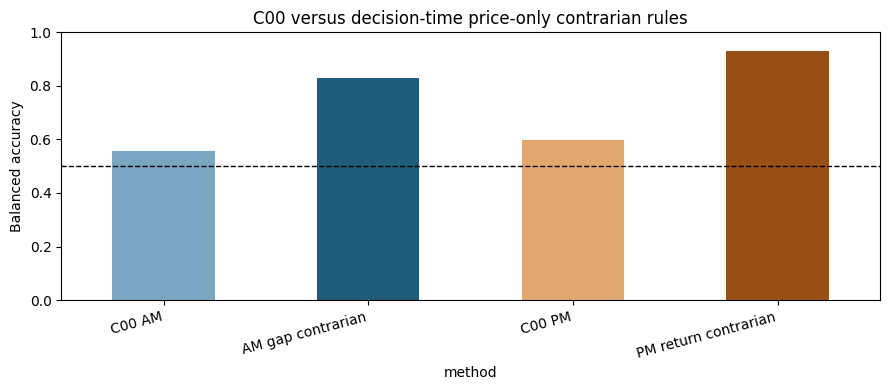

In [7]:
phase0 = sensitivity.loc[sensitivity['skip_initial_days'].eq(0)].set_index('phase')
base0 = price_baselines.loc[price_baselines['skip_initial_days'].eq(0)].set_index('subturn')
comparison = pd.DataFrame({
    'method': ['C00 AM', 'AM gap contrarian', 'C00 PM', 'PM return contrarian'],
    'balanced_accuracy': [
        phase0.loc['AM only', 'balanced_accuracy'],
        base0.loc['am', 'balanced_accuracy'],
        phase0.loc['PM only', 'balanced_accuracy'],
        base0.loc['pm', 'balanced_accuracy'],
    ]
})
ax = comparison.plot.bar(x='method', y='balanced_accuracy', legend=False, figsize=(9, 4), color=['#7aa6c2', '#1f5d7a', '#e2a66f', '#9a4f15'])
ax.axhline(0.5, color='black', linestyle='--', linewidth=1)
ax.set_ylim(0, 1)
ax.set_ylabel('Balanced accuracy')
ax.set_title('C00 versus decision-time price-only contrarian rules')
plt.xticks(rotation=15, ha='right')
plt.tight_layout()
plt.show()

These are the critical comparators. AM already observes the opening gap relative to the previous close; PM observes the current-day return. A mechanically contrarian rule using only those prompt-visible signals substantially outperforms the LLM flow. The PM rule is contemporaneous and therefore not an ex-ante forecast, but it is the correct same-information benchmark for a same-day reconstruction claim. The AM opening-gap rule is also much stronger than AM C00. Any future model must report incremental performance over these rules or target residual retail flow after a price-only model.

In [8]:
pd.DataFrame([audit['statistical_tests']]).drop(columns=['confusion_actual_by_predicted_buy_sell', 'note']).T.rename(columns={0: 'diagnostic p-value'})

,diagnostic p-value
one_sided_binomial_match_vs_half_p,0.116347
fixed_margins_hypergeometric_p,0.132570
fisher_exact_two_sided_p,0.221401
mcnemar_vs_always_buy_exact_two_sided_p,1.000000


### 2. Initialization and information-timing sensitivity

In [9]:
display_cols = ['phase', 'skip_initial_days', 'days', 'direction_match_rate',
                'balanced_accuracy', 'pearson', 'spearman']
sensitivity[display_cols].style.format({
    'direction_match_rate': '{:.1%}', 'balanced_accuracy': '{:.1%}',
    'pearson': '{:.3f}', 'spearman': '{:.3f}'
})

,phase,skip_initial_days,days,direction_match_rate,balanced_accuracy,pearson,spearman
0,AM only,0,45,53.3%,55.6%,0.369,0.185
1,AM only,1,44,52.3%,54.6%,0.042,0.128
2,AM only,3,42,52.4%,54.4%,-0.155,0.067
3,AM only,5,40,50.0%,51.9%,-0.250,-0.022
4,AM only,10,35,51.4%,52.8%,-0.076,0.058
5,PM only,0,45,60.0%,59.8%,0.415,0.346
6,PM only,1,44,59.1%,59.0%,0.357,0.309
7,PM only,3,42,59.5%,59.4%,0.286,0.280
8,PM only,5,40,60.0%,59.8%,0.284,0.275
9,PM only,10,35,60.0%,60.2%,0.175,0.185


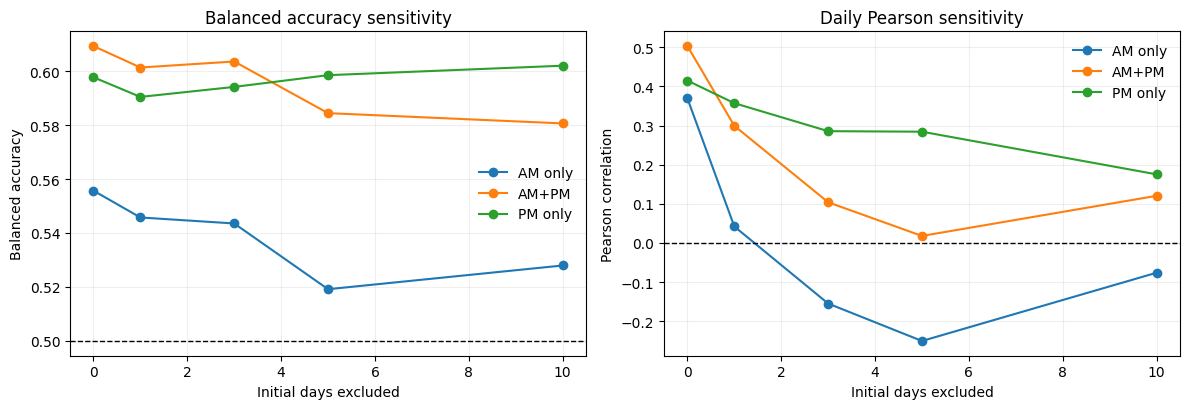

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
for phase, group in sensitivity.groupby('phase'):
    axes[0].plot(group['skip_initial_days'], group['balanced_accuracy'], marker='o', label=phase)
    axes[1].plot(group['skip_initial_days'], group['pearson'], marker='o', label=phase)
axes[0].axhline(0.5, color='black', linestyle='--', linewidth=1)
axes[0].set(title='Balanced accuracy sensitivity', xlabel='Initial days excluded', ylabel='Balanced accuracy')
axes[1].axhline(0, color='black', linestyle='--', linewidth=1)
axes[1].set(title='Daily Pearson sensitivity', xlabel='Initial days excluded', ylabel='Pearson correlation')
for ax in axes:
    ax.grid(alpha=.2)
    ax.legend(frameon=False)
plt.tight_layout()
plt.show()

The combined-flow Pearson falls from 0.503 to 0.018 after excluding five initial days. The first day is a synchronized deployment event: every agent starts with KRW 100 million, no holdings, and is buy-only. AM-only balanced accuracy is approximately chance after five days, while PM remains near 60%; PM has access to same-day context, so this is more naturally described as nowcasting or behavioral reconstruction than forecasting.

### 3. Forced action-space mechanics

In [11]:
feasibility.style.format({
    'mean_quantity': '{:.1f}', 'max_quantity_selected_rate': '{:.1%}'
})

,feasible_action_set,turn_rows,buy_rows,sell_rows,mean_quantity,max_quantity_selected_rate
0,both,2394,1385,1009,32.6,39.6%
1,buy_only,124,124,0,162.6,31.5%
2,sell_only,182,0,182,52.2,5.5%
3,neither,0,0,0,nan,nan%


In [12]:
pd.DataFrame([
    {
        'buy turns': audit['decision_mechanics']['buy_rows'],
        'sell turns': audit['decision_mechanics']['sell_rows'],
        'one-share turns': audit['decision_mechanics']['one_share_rows'],
        'one-share rate': metric_lookup['one_share_rate'],
        'turnover / initial capital': audit['decision_mechanics']['mean_agent_turnover_multiple'],
        'deterministic fallbacks': audit['decision_mechanics']['deterministic_fallback_rows'],
    }
]).style.format({'one-share rate': '{:.1%}', 'turnover / initial capital': '{:.2f}×'})

,buy turns,sell turns,one-share turns,one-share rate,turnover / initial capital,deterministic fallbacks
0,1509,1191,589,21.8%,7.09×,0


Hold is disabled, so all 2,700 turns must trade. In 306 turns only one direction is financially feasible. One-share orders are common and may partially proxy a desire to hold. Belief–action consistency therefore must condition on the feasible action set and distinguish desired stance from executed order.

### 4. Belief, news provenance, and runtime quality

In [13]:
trace = audit['belief_and_news_trace']
runtime = audit['llm_runtime']
pd.DataFrame([
    {
        'blank belief summaries': trace['blank_belief_summary_rows'],
        'blank view-change rows': trace['blank_view_change_rows'],
        'raw selected-news refs': trace['raw_influential_news_items'],
        'mapped refs': trace['mapped_influential_news_items'],
        'unmapped refs': trace['unmapped_influential_news_items'],
        'unmapped rate': trace['unmapped_influential_news_items'] / trace['raw_influential_news_items'],
        'API requests': runtime['api_requests'],
        'API errors': runtime['api_errors'],
        'validation retries': runtime['validation_retry_events'],
    }
]).style.format({'unmapped rate': '{:.1%}'})

,blank belief summaries,blank view-change rows,raw selected-news refs,mapped refs,unmapped refs,unmapped rate,API requests,API errors,validation retries
0,0,0,8957,143,8814,98.4%,13516,295,1053


In [14]:
llm_api.style.format({
    'error_rate': '{:.2%}', 'cost_usd': '${:.3f}',
    'mean_latency_seconds': '{:.1f}', 'p95_latency_seconds': '{:.1f}'
})

,label,requests,successes,errors,error_rate,cost_usd,total_tokens,mean_latency_seconds,p95_latency_seconds
0,belief_update,3482,3451,31,0.89%,$4.797,36482975,32.8,47.7
1,depth2_post_search,408,398,10,2.45%,$0.500,3529811,25.6,40.8
2,depth2_pre_search,382,382,0,0.00%,$0.476,3099055,90.6,194.5
3,market_analysis,2865,2861,4,0.14%,$3.629,18419736,28.3,42.3
4,news_interpretation,3023,2993,30,0.99%,$3.736,24143279,79.7,198.8
5,trading_decision,3356,3136,220,6.56%,$4.142,24614901,31.9,54.3


Belief fields are complete and previous-belief continuity is intact, but selected-news normalization is broken for ID strings: 98.4% of raw selected references are left unmapped. This blocks automated source-grounding scores until an offline repair joins raw IDs back to visible/search news. Final outputs recover from retries, yet retry/error rates should remain reported as system-quality outcomes.

### 5. Persona descriptives

In [15]:
persona.loc[
    persona['persona_axis'].isin(['strategy', 'news_depth', 'age_group', 'gender']),
    ['persona_axis', 'persona_value', 'agent_count', 'buy_share', 'one_share_rate',
     'decision_retry_rate', 'direction_match_rate', 'balanced_accuracy']
].style.format({
    'buy_share': '{:.1%}', 'one_share_rate': '{:.1%}',
    'decision_retry_rate': '{:.1%}', 'direction_match_rate': '{:.1%}',
    'balanced_accuracy': '{:.1%}'
})

,persona_axis,persona_value,agent_count,buy_share,one_share_rate,decision_retry_rate,direction_match_rate,balanced_accuracy
0,strategy,technical,16,57.6%,18.0%,7.7%,55.6%,53.9%
1,strategy,value,14,53.9%,26.2%,7.8%,57.8%,58.0%
2,news_depth,0,10,55.2%,20.4%,9.8%,48.9%,49.7%
3,news_depth,1,16,58.6%,25.1%,6.9%,60.0%,60.9%
4,news_depth,2,4,46.7%,12.2%,5.8%,53.3%,54.4%
5,age_group,20대,9,55.2%,16.9%,6.9%,62.2%,62.7%
6,age_group,30대,18,55.8%,24.9%,7.8%,57.8%,59.1%
7,age_group,40대,3,58.5%,17.8%,10.0%,60.0%,59.8%
8,gender,female,17,53.5%,22.9%,7.7%,51.1%,51.5%
9,gender,male,13,59.0%,20.3%,7.8%,62.2%,62.7%


These rows are exploratory only. The active cohort is the deterministic first 30 IDs, every agent has the same KRW 100 million endowment, news-depth 2 has only four agents, and age 40s has only three. A stronger construct-validity experiment clones the same base persona and changes exactly one trait at a time.

In [16]:
persona_construct.pivot(index='category', columns='construct', values='value').reindex(['low', 'medium', 'high'])

construct,disposition_effect,lottery_risk_preference
category,,
low,0.152985,0.521463
medium,0.313365,0.576798
high,0.439685,0.705853


In [17]:
pd.DataFrame({
    name: audit['persona_construct_validity'][name]
    for name in ['disposition_ordinal_spearman', 'risk_ordinal_spearman']
}).T

,rho,p_exploratory
disposition_ordinal_spearman,0.445126,0.013707
risk_ordinal_spearman,0.597058,0.000496


The monotone disposition and normalized-order-intensity patterns are prompt-enactment construct checks, not evidence about human demographic groups. Their p-values are exploratory because traits were not independently randomized, the sample contains 30 agents, and multiple checks were considered.

## Takeaways

1. Treat this as a 45-day sealed partial baseline, not the configured 63-day completed experiment.
2. Report balanced accuracy, both class recalls, always-buy, prior-day, AM opening-gap, and PM current-return contrarian baselines alongside the 60% match rate.
3. Add hold and separate belief → intended exposure → feasibility allocation → execution before adding sophisticated memory.
4. Repair selected-news provenance before rubric/embedding source-grounding analysis or any fake-news condition.
5. The strongest new paper asks when source-aware short/long memory and reflection improve alignment beyond price-only contrarian behavior and when they preserve misinformation. Memory is an experimental treatment, not an assumed improvement.